In [91]:
import numpy as np
import pandas as pd
from numpy.linalg import eigh
from statsmodels.api import OLS, add_constant
import yfinance as yf

In [92]:
# ---------------------------
# 参数
# ---------------------------
lookback = 252
num_factors = 5
topN = 3

In [93]:
# ---------------------------
# 工具函数
# ---------------------------
def lag1(x):
    return x.shift(1)

def smartmean(x, axis=0):
    return np.nanmean(x, axis=axis)

def smartcov(x):
    """
    x: shape (T, N)
    rows = observations, columns = variables
    normalize by N (not N-1)
    """
    x = np.asarray(x)
    mu = np.nanmean(x, axis=0)
    xc = x - mu

    cov = np.nanmean(
        xc[:, :, None] * xc[:, None, :],
        axis=0
    )
    return cov

In [94]:
# import os
# proxy = 'http://127.0.0.1:7897'	# 代理设置，此处修改
# os.environ['HTTP_PROXY'] = proxy 
# os.environ['HTTPS_PROXY'] = proxy 

In [95]:
# ---------------------------
# 数据准备
# ---------------------------
symbols = [
    "SMCI", "ATI", "ELF", "CROX", "FNKO",
    "BOOT", "CAL", "GEO", "VRT", "SNDR"
]

symbols = [s.replace(".", "-") for s in symbols]

cl = yf.download(
    symbols,
    start="2015-01-01",
    end="2024-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

cl = cl.sort_index()
cl = cl.dropna(how="all", axis=1)

mycls = cl.ffill()
mycls

Ticker,ATI,BOOT,CAL,CROX,ELF,FNKO,GEO,SMCI,SNDR,VRT
Date,,,,,,,,,,
2015-01-02,32.917793,17.940001,27.074347,12.490000,NaN,NaN,15.302588,3.473000,NaN,NaN
2015-01-05,31.012983,18.000000,26.884834,12.610000,NaN,NaN,15.400518,3.367000,NaN,NaN
2015-01-06,30.237659,18.290001,25.635777,12.080000,NaN,NaN,15.325186,3.276000,NaN,NaN
2015-01-07,30.773684,18.540001,26.600559,11.700000,NaN,NaN,15.505970,3.300000,NaN,NaN
2015-01-08,30.945978,19.299999,27.539501,11.820000,NaN,NaN,15.536101,3.473000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2023-12-22,45.610001,77.150002,29.692249,98.180000,143.839996,7.14,11.230000,28.972000,24.982935,48.652306
2023-12-26,46.250000,78.669998,30.401985,96.699997,143.740005,7.20,11.150000,29.433001,25.060553,48.861755
2023-12-27,46.180000,78.779999,30.713106,94.510002,144.050003,7.26,11.150000,29.500000,24.759785,48.801914


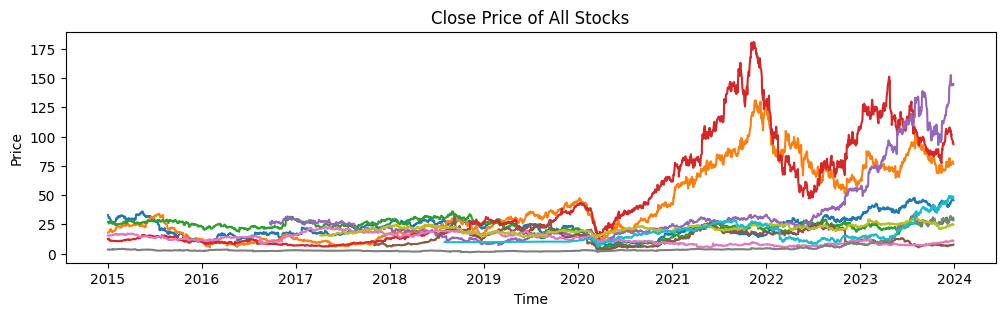

In [96]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,3))
plt.plot(mycls)
plt.title("Close Price of All Stocks")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

In [97]:
dailyret = (mycls - lag1(mycls)) / lag1(mycls)
dailyret = dailyret.dropna()

In [98]:
positions = pd.DataFrame(
    0,
    index=dailyret.index,
    columns=dailyret.columns
)

# ======================
# 参数
# ======================
halflife = 15
alpha = 1 - np.exp(np.log(0.5) / halflife)

exit_buffer = 5
exit_band = topN + exit_buffer

Rexp_smooth_prev = None

# ======================
# 主循环
# ======================
for t in range(lookback, len(dailyret)):
    window = dailyret.iloc[t - lookback:t]

    # R: (N, T)
    R = window.T.values

    has_data = np.all(np.isfinite(R), axis=1)
    stk_idx = np.where(has_data)[0]
    R = R[has_data]

    if R.shape[0] < num_factors + 1:
        continue

    avgR = smartmean(R, axis=1)
    R = R - avgR[:, None]

    # covR: (N, N)
    covR = smartcov(R.T)

    # eigvals:(10,) eigvecs:(10, 10)
    eigvals, eigvecs = eigh(covR)
    
    X = eigvecs[:, -num_factors:]
    y = R[:, -1]
    b = np.linalg.lstsq(X, y, rcond=None)[0]

    Rexp = avgR + X @ b

    # ========= 平滑 =========
    if Rexp_smooth_prev is None:
        Rexp_smooth = Rexp.copy()
    else:
        Rexp_smooth = alpha * Rexp + (1 - alpha) * Rexp_smooth_prev

    Rexp_smooth_prev = Rexp_smooth.copy()

    # ========= 排名 =========
    order = np.argsort(Rexp_smooth)
    n = len(order)

    positions.iloc[t] = positions.iloc[t - 1]

    # ========= holding period =========
    # -------- 先 exit --------
    long_exit  = stk_idx[order[:n - exit_band]]
    short_exit = stk_idx[order[exit_band:]]

    positions.iloc[t, long_exit] = 0
    positions.iloc[t, short_exit] = 0

    # -------- 再 enter --------
    long_enter  = stk_idx[order[-topN:]]
    short_enter = stk_idx[order[:topN]]

    positions.iloc[t, long_enter] = 1
    positions.iloc[t, short_enter] = -1

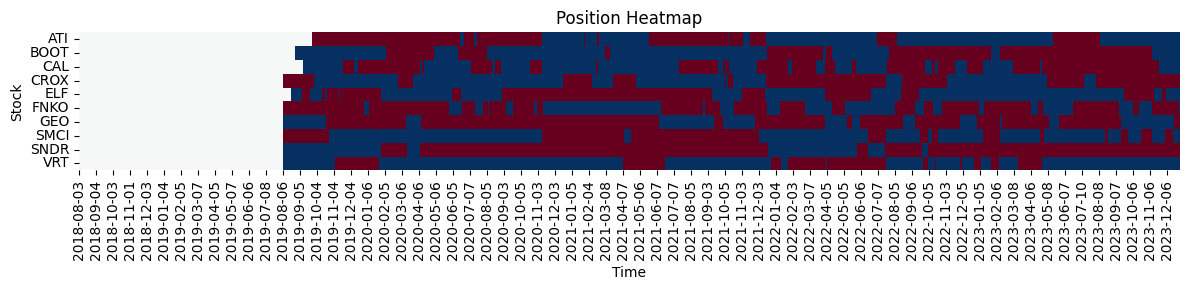

In [99]:
import seaborn as sns
pos_plot = positions.copy()
pos_plot.index = pos_plot.index.date
plt.figure(figsize=(12, 3))
sns.heatmap(
    pos_plot.T,
    cmap="RdBu",
    center=0,
    cbar=False
)
plt.title("Position Heatmap")
plt.xlabel("Time")
plt.ylabel("Stock")
plt.tight_layout()
plt.show()

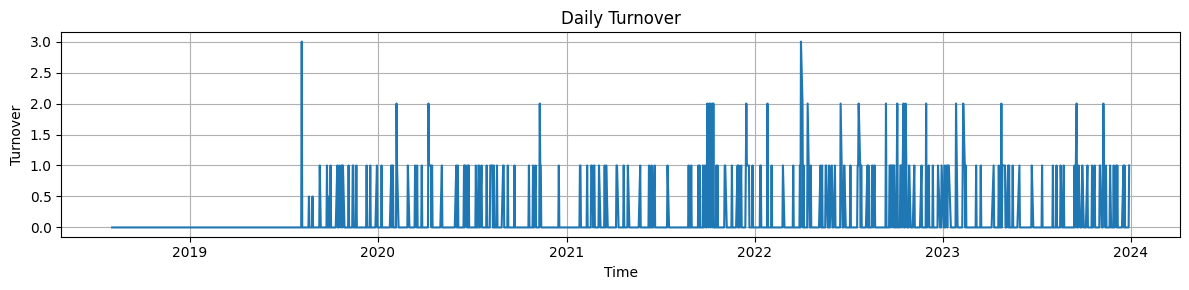

In [100]:
turnover = positions.diff().abs().sum(axis=1) / 2

plt.figure(figsize=(12, 3))
plt.plot(turnover)
plt.title("Daily Turnover")
plt.ylabel("Turnover")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.show()

In [101]:
# ---------------------------
# 策略收益
# ---------------------------
gross_exposure = positions.abs().sum(axis=1)
ret = (positions.shift(1) * dailyret).sum(axis=1) / gross_exposure.shift(1)
avgret = ret.mean() * 252

print("Annualized return:", avgret)

Annualized return: 0.19301509157834512


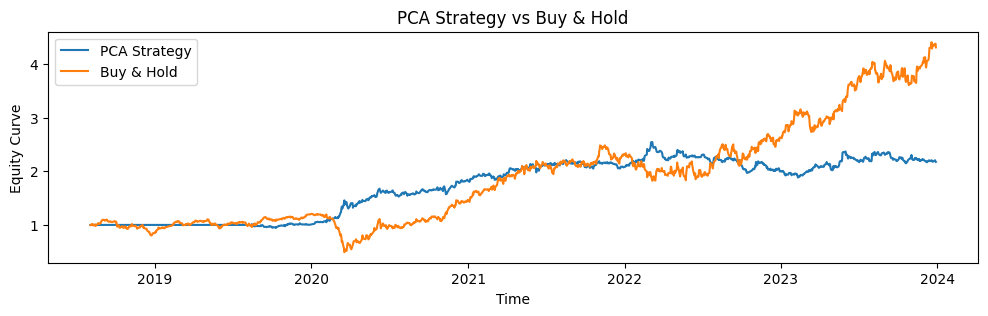

In [102]:
import matplotlib.pyplot as plt

# Buy & Hold：等权持有所有股票
bh_ret = dailyret.mean(axis=1)

# 累计净值
eq_strategy = (1 + ret.fillna(0)).cumprod()
eq_bh = (1 + bh_ret.fillna(0)).cumprod()

# 对齐时间
df = eq_strategy.to_frame("PCA Strategy").join(
    eq_bh.to_frame("Buy & Hold"),
    how="inner"
)

# 画图（单图，不指定颜色）
plt.figure(figsize=(12,3))
plt.plot(df.index, df["PCA Strategy"], label="PCA Strategy")
plt.plot(df.index, df["Buy & Hold"], label="Buy & Hold")
plt.title("PCA Strategy vs Buy & Hold")
plt.xlabel("Time")
plt.ylabel("Equity Curve")
plt.legend()
plt.show()
